In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

In [3]:
milk = pd.read_csv(r"monthly_milk_production.csv")
milk.head()

,Date,Production
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727


In [4]:
milk.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Date        168 non-null    object
 1   Production  168 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.8+ KB


In [5]:
milk["Date"] = pd.to_datetime(milk["Date"])

In [6]:
milk.columns = milk.columns.str.strip()
print(milk.columns)

Index(['Date', 'Production'], dtype='object')


In [7]:
milk = milk.set_index('Date').sort_index()

In [8]:
milk.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 168 entries, 1962-01-01 to 1975-12-01
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Production  168 non-null    int64
dtypes: int64(1)
memory usage: 2.6 KB


In [9]:
milk.head()

,Production
Date,
1962-01-01,589
1962-02-01,561
1962-03-01,640
1962-04-01,656
1962-05-01,727


In [10]:
milk.isnull().sum()

Production    0
dtype: int64

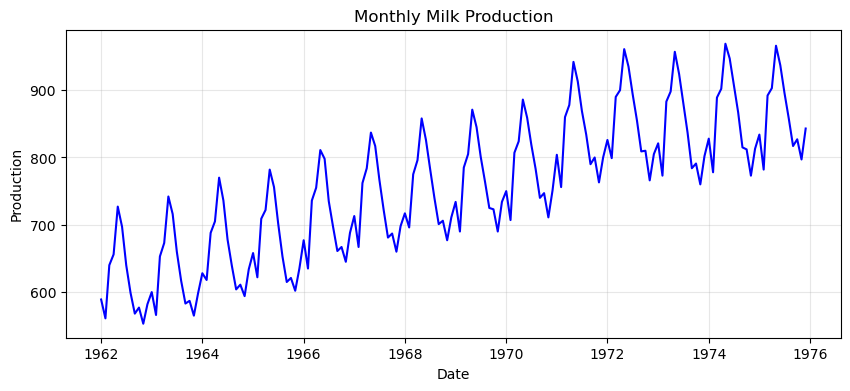

In [14]:
plt.figure(figsize = (10,4))
plt.plot(milk.index,milk["Production"], color = "blue")
plt.title("Monthly Milk Production")
plt.xlabel("Date")
plt.ylabel("Production")
plt.grid(True,alpha = 0.3)
plt.show()

In [17]:
milk["Month"] = milk.index.month
monthly_seasonality = milk.groupby("Month")["Production"].mean()
print(monthly_seasonality)

Month
1     727.071429
2     689.285714
3     783.500000
4     800.071429
5     862.785714
6     836.142857
7     788.071429
8     747.500000
9     706.642857
10    711.857143
11    682.571429
12    721.000000
Name: Production, dtype: float64


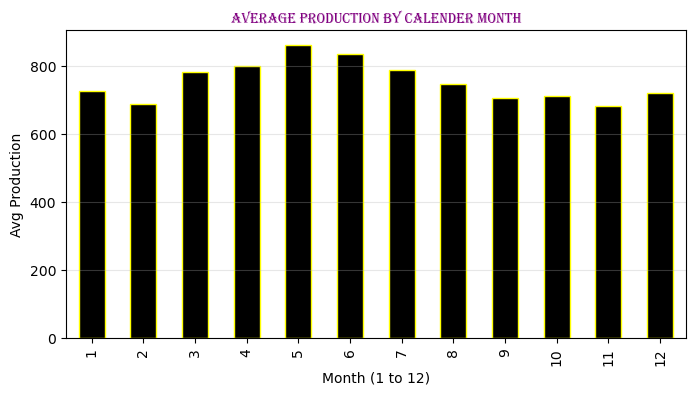

In [21]:
plt.figure(figsize =(8,4))
monthly_seasonality.plot(kind="bar",color ="black", edgecolor = 'yellow')
plt.title ("Average Production by calender Month", color='purple', size=16, weight = 'bold', style='italic', font='algerian')
plt.xlabel("Month (1 to 12)")
plt.ylabel("Avg Production")
plt.grid (True ,axis = "y",alpha =0.3)
plt.show()

In [20]:
milk["Production_rolling12"] = milk["Production"].rolling(window = 12).mean()

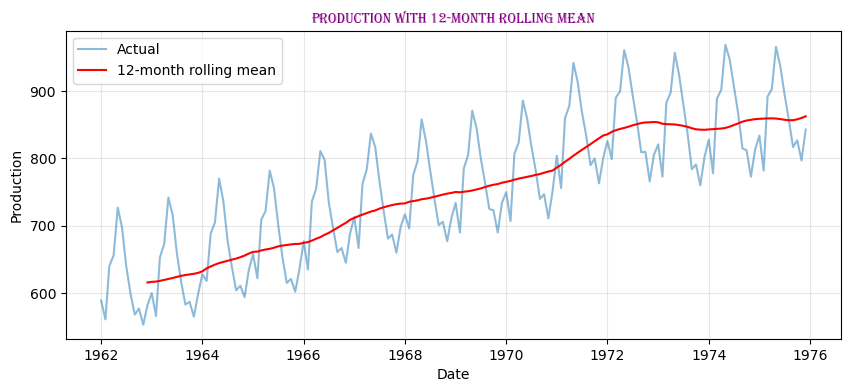

In [23]:
plt.figure(figsize=(10, 4))
plt.plot(milk.index, milk['Production'], label='Actual', alpha=0.5)
plt.plot(milk.index, milk['Production_rolling12'], label='12-month rolling mean', color='red')
plt.title('Production with 12-month Rolling Mean',  color='purple', size=16, weight = 'bold', style='italic', font='algerian')
plt.xlabel('Date')
plt.ylabel('Production')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [25]:
milk= milk.drop(columns=["Month","Production_rolling12"],errors= "ignore")


In [26]:
from sklearn.preprocessing import MinMaxScaler

In [27]:
values = milk["Production"].values.reshape(-1,1)

In [28]:
scaler = MinMaxScaler()
scaler

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False


In [29]:
values_scaled = scaler.fit_transform(values)

In [30]:
def make_sequences(series,window = 12,horizon =1):
    x=[]
    y=[]
    for i in range(len(series)-window-horizon +1):
        x.append(series[i:i+window])
        y.append(series[i+window:i+window+horizon])
    x = np.array(x)
    y = np.array(y).reshape(-1,horizon)
    return x,y

In [31]:
WINDOW = 12
HORIZON = 1
x_all, y_all = make_sequences(values_scaled, 
                              window=WINDOW,
                              horizon=HORIZON)

In [32]:
n= len(x_all)
n_train = int(n*0.7)
n_val = int(n*0.15)
n_test = n- n_train -n_val

x_train,y_train = x_all[:n_train],y_all[:n_train]
x_val,y_val =x_all[n_train:n_train+n_val],y_all[n_train:n_train+n_val]
x_test,y_test = x_all [n_train +n_val:],y_all[n_train+n_val:]

In [33]:
print(f"Samples -> Train: {len(x_train)}, Val: {len(x_val)}, Test: {len(x_test)}")
print(f"Input shape per sample: {x_train.shape[1:]} (window, features)")

Samples -> Train: 109, Val: 23, Test: 24
Input shape per sample: (12, 1) (window, features)


In [34]:
import tensorflow as tf
from tensorflow.keras.models import  Sequential
from tensorflow.keras.layers import Dense,SimpleRNN,LSTM,GRU,Dropout
from tensorflow.keras.callbacks import EarlyStopping 

In [35]:
UNITS = 32
DROPOUT =0.1
EPOCHS = 100
BATCH_SIZE = 16 
ES = EarlyStopping(monitor = "val_loss",patience = 10 ,restore_best_weights =True)

In [36]:
# RNN model 
def build_rnn_model():
    model = Sequential([
        SimpleRNN(UNITS,input_shape=(WINDOW,1)),
        Dropout(DROPOUT),
        Dense(1)
    ])
    model.compile(optimizer = "adam",loss="mse")
    return model

In [37]:
# LSTM model 
def build_lstm_model():
    model =Sequential([
        LSTM(UNITS,input_shape = (WINDOW,1)),
        Dropout(DROPOUT),
        Dense(1)
    ])
    model.compile(optimizer = "adam",loss = "mse")
    return model 

In [38]:
def build_gru_model():
    model = Sequential([
        GRU(UNITS, input_shape=(WINDOW, 1)),
        Dropout(DROPOUT),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

In [39]:
rnn_model  = build_rnn_model()
lstm_model = build_lstm_model()
gru_model  = build_gru_model()

C:\Users\VIK\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [40]:
RNN = rnn_model.fit(x_train,y_train,validation_data = (x_val,y_val),
                    epochs = EPOCHS,batch_size = BATCH_SIZE,callbacks=[ES],verbose =0)

In [41]:
LSTM =lstm_model.fit(x_train,y_train,validation_data = (x_val,y_val),
                    epochs = EPOCHS,batch_size = BATCH_SIZE,callbacks=[ES],verbose =0)

In [42]:
GRU = gru_model.fit(x_train,y_train,validation_data = (x_val,y_val),
                    epochs = EPOCHS,batch_size = BATCH_SIZE,callbacks=[ES],verbose =0)

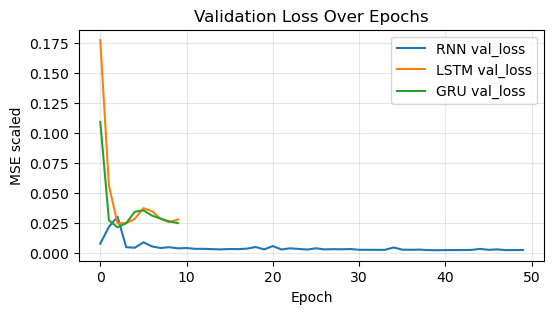

In [43]:
# plot training curves compare of RNN ,LSTM,GRU 
plt.figure(figsize=(6,3))
plt.plot(RNN.history['val_loss'],  label='RNN val_loss')
plt.plot(LSTM.history['val_loss'], label='LSTM val_loss')
plt.plot(GRU.history['val_loss'],  label='GRU val_loss')
plt.title('Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MSE scaled')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [44]:
from sklearn.metrics import mean_squared_error,mean_absolute_error


In [45]:
def inverse_transform(pred_scaled):
    return scaler.inverse_transform(pred_scaled.reshape(-1,1)).ravel()


In [46]:
def evaluate_model (model,x,y,label= "Model"):
    y_pred_scaled = model.predict(x,verbose =0).ravel()
    y_true_scaled = y.ravel()
    
    y_pred = inverse_transform(y_pred_scaled)
    y_true = inverse_transform(y_true_scaled)

    rmse = np.sqrt(mean_squared_error(y_true,y_pred))
    mae = mean_absolute_error(y_true,y_pred)
    mape =np.mean(np.abs((y_true -y_pred)/y_true))*100

    print(f"{label} -> RMSE: {rmse:.2f}, MAE: {mae:.2f}, MAPE: {mape:.2f}%")
    return {'RMSE': rmse, 'MAE': mae, 'MAPE': mape}, y_true, y_pred

In [47]:
metrics_rnn,  y_true_rnn,  y_pred_rnn  = evaluate_model(rnn_model,  x_test, y_test, label='RNN')
metrics_lstm, y_true_lstm, y_pred_lstm = evaluate_model(lstm_model, x_test, y_test, label='LSTM')
metrics_gru,  y_true_gru,  y_pred_gru  = evaluate_model(gru_model,  x_test, y_test, label='GRU')

RNN -> RMSE: 19.21, MAE: 16.07, MAPE: 1.87%
LSTM -> RMSE: 183.05, MAE: 173.11, MAPE: 19.75%
GRU -> RMSE: 144.27, MAE: 132.95, MAPE: 15.10%


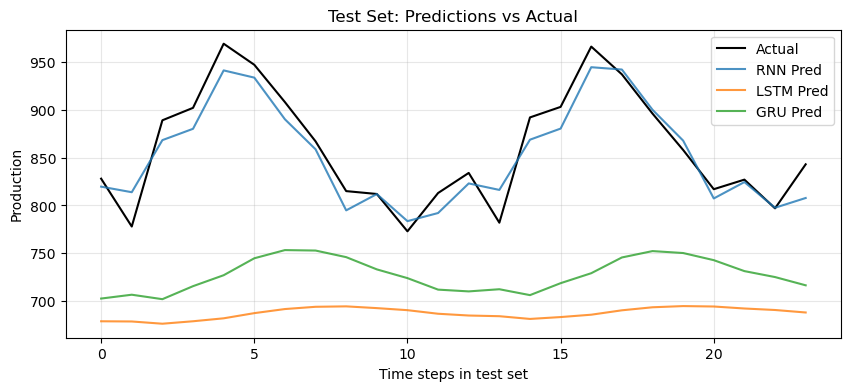

In [48]:
# Compare predictions vs actual (test set)
plt.figure(figsize=(10, 4))
plt.plot(y_true_lstm, label='Actual', color='black')
plt.plot(y_pred_rnn,  label='RNN Pred',  alpha=0.8)
plt.plot(y_pred_lstm, label='LSTM Pred', alpha=0.8)
plt.plot(y_pred_gru,  label='GRU Pred',  alpha=0.8)
plt.title('Test Set: Predictions vs Actual')
plt.xlabel('Time steps in test set')
plt.ylabel('Production')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [49]:
# Pick the best model by RMSE 
def pick_best_model(metrics_dict):
    best_name = min(metrics_dict.keys(), key=lambda k: metrics_dict[k]['RMSE'])
    return best_name

In [50]:
models_metrics = {'RNN': metrics_rnn, 'LSTM': metrics_lstm, 'GRU': metrics_gru}
best_name = pick_best_model(models_metrics)
best_model = {'RNN': rnn_model, 'LSTM': lstm_model, 'GRU': gru_model}[best_name]
print(f"Best model based on RMSE: {best_name}")

Best model based on RMSE: RNN


In [51]:
last_window_scaled = values_scaled[-WINDOW:].copy()

In [52]:
future_preds = []
current_window = last_window_scaled.copy()

for step in range(12):
    pred_scaled = best_model.predict(current_window.reshape(1, WINDOW, 1), verbose=0).ravel()[0]
    future_preds.append(pred_scaled)
    current_window = np.vstack([current_window[1:], [[pred_scaled]]])

In [53]:
future_preds_unscaled = inverse_transform(np.array(future_preds))
future_preds_unscaled 

array([836.84357, 819.6561 , 876.5704 , 881.1132 , 929.9707 , 919.22156,
       895.496  , 867.0824 , 823.3294 , 834.3842 , 811.0932 , 834.6029 ],
      dtype=float32)

In [55]:
last_date = milk.index[-1]
future_index = pd.date_range(last_date + pd.offsets.MonthBegin(1), periods=12, freq='MS')
forecast_df = pd.DataFrame({'Forecast': future_preds_unscaled}, index=future_index)

print("\nNext 12 months forecast (head):")
print(forecast_df.head())


Next 12 months forecast (head):
              Forecast
1976-01-01  836.843567
1976-02-01  819.656128
1976-03-01  876.570374
1976-04-01  881.113220
1976-05-01  929.970703


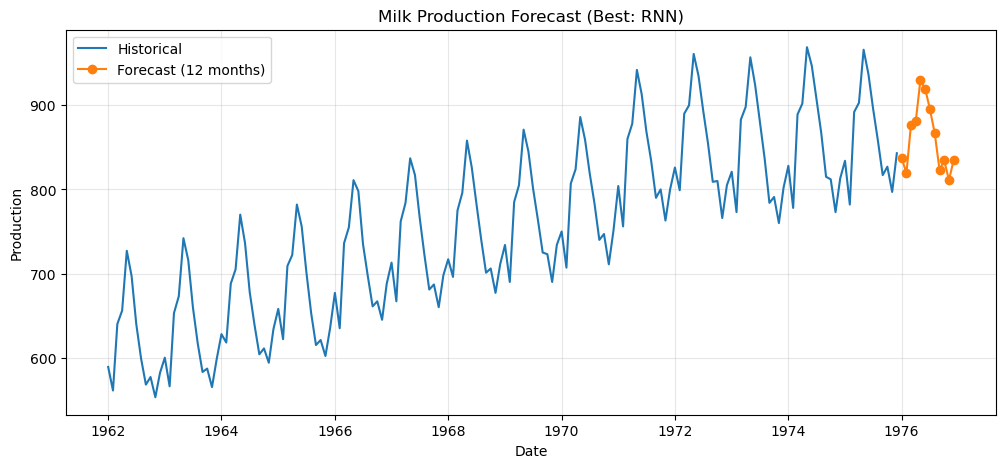

In [57]:
plt.figure(figsize=(12, 5))
plt.plot(milk.index, milk['Production'], label='Historical', color='tab:blue')
plt.plot(forecast_df.index, forecast_df['Forecast'], label='Forecast (12 months)', color='tab:orange', marker='o')
plt.title(f'Milk Production Forecast (Best: {best_name})')
plt.xlabel('Date')
plt.ylabel('Production')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Business Insights from Forecasts
1. Supply Chain & Distribution:- Forecasts highlight seasonal peaks typically mid-year and dips end of year.
 **Action:** Align logistics and transportation capacity with peak months to avoid bottlenecks. During low-production months, reduce distribution runs to save costs.

2. Inventory & Storage:- Predicted surpluses in high-production months require extra cold storage capacity.
**Action:** Plan for storage expansion or rental facilities. During lean months, optimize storage usage to minimize wastage and refrigeration costs.

3. Workforce & Operations: Seasonal fluctuations mean staffing needs vary.
**Action:** Schedule additional labor shifts or temporary workers during peak months. Use low-production months for maintenance, training, and equipment servicing.

4. Financial Planning:- Forecasts allow cash flow planning by anticipating revenue fluctuations.
**Action:** Secure short-term financing or adjust pricing strategies during low-production months. Negotiate contracts with buyers based on forecasted supply.

5. Strategic Growth:- Long-term upward trend suggests scaling opportunities.
**Action:** Invest in herd expansion, feed quality, or automation to sustain growth. Use forecasts to justify capital investments and expansion plans.

6. Risk Management:- Forecasts help identify uncertainty bands (confidence intervals).
**Action:** Build contingency plans for unexpected drops (disease, weather shocks). Diversify product lines (cheese, yogurt) to absorb fluctuations in raw milk supply.

 # Recommendations
 
 **A)** Update forecasts monthly with new data to keep them relevant.
 **B)** Compare models (RNN, LSTM, GRU) regularly and adopt the most accurate one.
 **C)** Integrate external factors (temperature, feed costs, holidays) into future models for better accuracy.
 **D)** Communicate forecasts to stakeholders (farm managers, distributors, retailers) so everyone aligns with expected production.
